In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from latex_io import format_matrix

plt.rcParams.update(
    {
        "font.size": 14,
        "axes.titlesize": 16,
        "axes.labelsize": 14,
        "xtick.labelsize": 12,
        "ytick.labelsize": 12,
        "legend.fontsize": 12,
        "figure.titlesize": 18,
    }
)
plt.rcParams["figure.figsize"] = (8, 5)

In [2]:
# import dataset
df = pd.read_excel("data/Assignment_Dataset_2.xlsx", sheet_name=0)


In [3]:
# do pca for df, but ignore gender and accomodation_class
features = ["DSRI", "GMI", "AQI", "SGI", "DEPI", "SGAI", "ACCR", "LEVI"]
X = df[features].to_numpy()
mean = np.mean(X, axis=0)
std = np.std(X, axis=0)
X_std = (X - mean) / std  # standardize data
varicance = np.var(X_std)
cov = np.cov(X_std.T)  # covariance matrix
print("cov matrix: ")
print(format_matrix(cov, 2))

cov matrix: 
\begin{pmatrix}
1.00 & -0.03 & -0.01 & -0.15 & 0.02 & 0.47 & 0.02 & 0.15 \\
-0.03 & 1.00 & 0.00 & -0.02 & -0.01 & -0.03 & -0.00 & -0.07 \\
-0.01 & 0.00 & 1.00 & -0.03 & -0.02 & 0.00 & -0.05 & 0.07 \\
-0.15 & -0.02 & -0.03 & 1.00 & -0.07 & -0.05 & 0.07 & 0.07 \\
0.02 & -0.01 & -0.02 & -0.07 & 1.00 & -0.07 & -0.02 & -0.01 \\
0.47 & -0.03 & 0.00 & -0.05 & -0.07 & 1.00 & -0.09 & 0.02 \\
0.02 & -0.00 & -0.05 & 0.07 & -0.02 & -0.09 & 1.00 & -0.01 \\
0.15 & -0.07 & 0.07 & 0.07 & -0.01 & 0.02 & -0.01 & 1.00
\end{pmatrix}


Eigenvalues:
[1.54549636 1.14233916 1.07127539 1.03628256 0.96653732 0.92227929
 0.84566568 0.47658627]
Sum eigenvalues:  8.006462035541196
Shape of PCs: (1239, 8)
Explained variance:
PC1: 0.193
PC2: 0.143
PC3: 0.134
PC4: 0.129
PC5: 0.121
PC6: 0.115
PC7: 0.106
PC8: 0.060


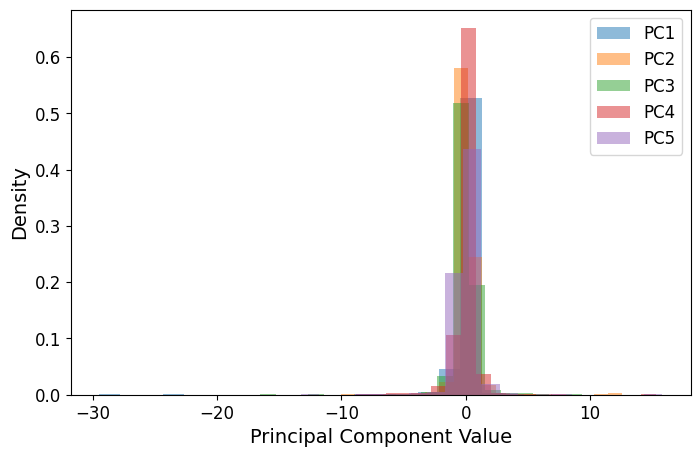

In [4]:
# Eigenvalues / Eigenvectors
eigenvalues, eigenvectors = np.linalg.eigh(cov)
idx = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]
print("Eigenvalues:")
print(eigenvalues)
print("Sum eigenvalues: ", sum(eigenvalues))

# Projection onto principal components
PCs = X_std @ eigenvectors
print("Shape of PCs:", PCs.shape)

explained_variance = eigenvalues / np.sum(eigenvalues)

print("Explained variance:")
for i, var in enumerate(explained_variance):
    print(f"PC{i+1}: {var:.3f}")
labels = ["PC1", "PC2", "PC3", "PC4", "PC5", "PC6", "PC7", "PC8"]
# plt.figure(figsize=(8, 5))
for i in range(5):
    plt.hist(PCs[:, i], bins=20, alpha=0.5, density=True, label=labels[i])

plt.xlabel("Principal Component Value")
plt.ylabel("Density")
plt.legend()
plt.savefig("pictures/pca2.pdf", bbox_inches="tight")
plt.show()

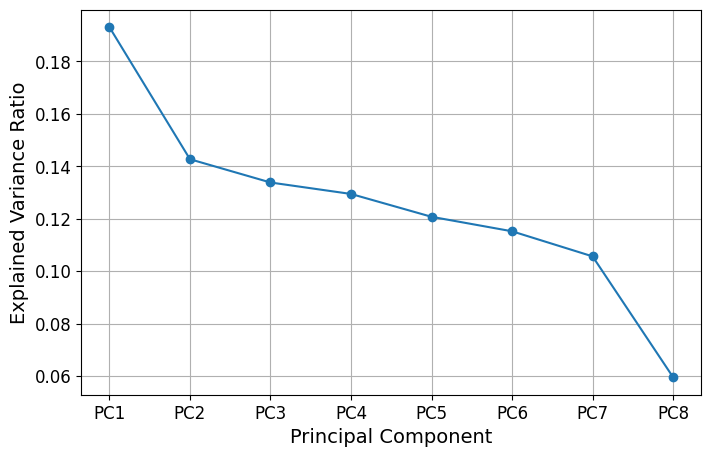

In [5]:
# Scree
# plt.figure(figsize=(6, 4))
plt.plot(range(1, len(explained_variance) + 1), explained_variance, marker="o")
plt.xticks(range(1, len(labels) + 1), labels)
plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.grid(True)
plt.savefig("pictures/screeplot2.pdf", bbox_inches="tight")
plt.show()

           PC1       PC2       PC3       PC4       PC5       PC6       PC7  \
DSRI -0.678786  0.011439  0.153132 -0.074219  0.166977  0.024106 -0.043094   
GMI   0.091696 -0.351596  0.110853  0.513647  0.573783  0.511321  0.018632   
AQI  -0.038486  0.129200 -0.702734  0.230227  0.373101 -0.385717 -0.381326   
SGI   0.226599  0.597859  0.174801  0.108149 -0.128229  0.398574 -0.588434   
DEPI  0.021873 -0.367591 -0.151931 -0.730443  0.194981  0.300577 -0.411531   
SGAI -0.646267  0.000834  0.160684  0.183083 -0.120899  0.008851 -0.314335   
ACCR  0.124491  0.264339  0.537150 -0.216252  0.607584 -0.429315 -0.031245   
LEVI -0.210654  0.545089 -0.320060 -0.228312  0.255837  0.394455  0.486817   

           PC8  
DSRI  0.692706  
GMI  -0.028757  
AQI   0.039934  
SGI   0.165550  
DEPI -0.100233  
SGAI -0.639920  
ACCR -0.157752  
LEVI -0.214242  


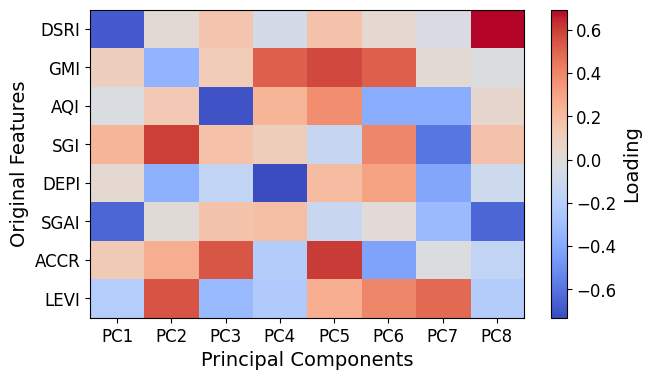

In [6]:
loadings = pd.DataFrame(eigenvectors, index=features, columns=labels)
print(loadings)
plt.figure(figsize=(7, 4))
plt.imshow(loadings, cmap="coolwarm", aspect="auto")
plt.xticks(range(len(labels)), labels)
plt.yticks(range(len(features)), features)
plt.colorbar(label="Loading")
plt.xlabel("Principal Components")
plt.ylabel("Original Features")
plt.savefig("pictures/loading_pca2.pdf", bbox_inches="tight")
plt.show()



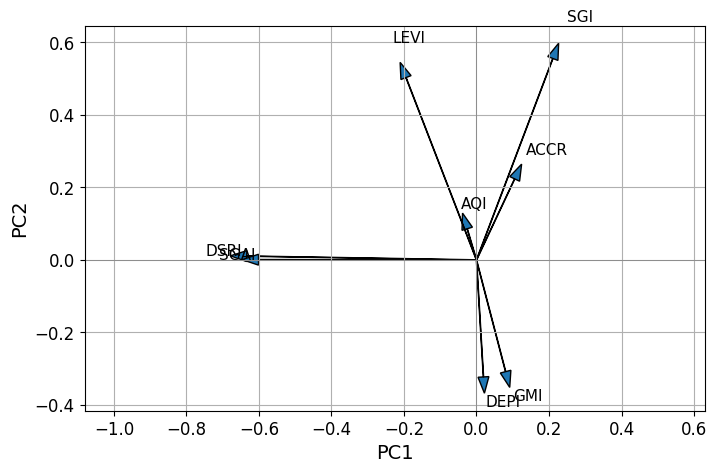

In [7]:
# plt.figure(figsize=(7, 7))
for i, feature in enumerate(features):
    plt.arrow(
        0,
        0,
        eigenvectors[i, 0],
        eigenvectors[i, 1],
        head_width=0.03,
        length_includes_head=True,
    )
    plt.text(eigenvectors[i, 0] * 1.1, eigenvectors[i, 1] * 1.1, feature, fontsize=11)

plt.axhline(0, color="gray", linewidth=0.5)
plt.axvline(0, color="gray", linewidth=0.5)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.axis("equal")
plt.grid(True)
plt.show()



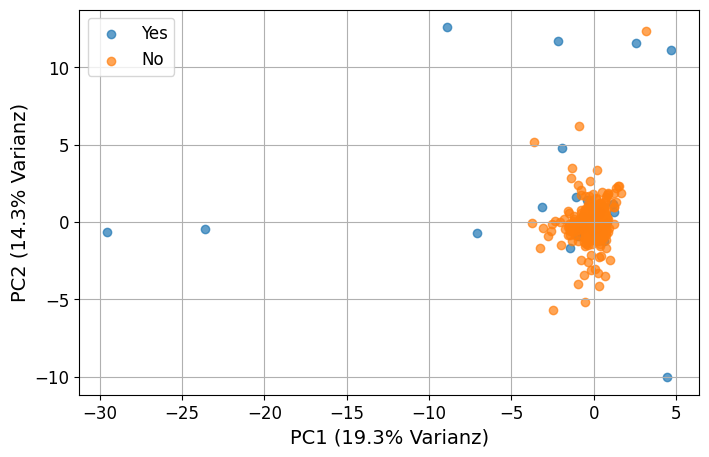

In [8]:

colors = {"Yes": "tab:blue", "No": "tab:red"}

# plt.figure(figsize=(7, 6))

for decision in colors:
    mask = df["Manipulater"] == decision

    plt.scatter(PCs[mask, 0], PCs[mask, 1], label=decision, alpha=0.7)  # PC1  # PC2

plt.xlabel(f"PC1 ({explained_variance[0]*100:.1f}% Varianz)")
plt.ylabel(f"PC2 ({explained_variance[1]*100:.1f}% Varianz)")
plt.legend()
plt.grid(True)
plt.savefig("pictures/pc1vspc2_2.pdf", bbox_inches="tight")
plt.show()
